# Klebeilla ATB

In [2]:
# Comprehensive analysis of K. pneumoniae data with consistent ST ordering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Load the data
k_file = "/Users/davidabelson/Library/CloudStorage/OneDrive-UniversityofCambridge/Code_repos/md_curation/atb-0.2-kleborate.v2.3.2-merged.tsv"
kleborate_data = pd.read_csv(k_file, sep="\t")

display(kleborate_data.head(3))
print(f"kleborate_data.columns: {kleborate_data.columns.tolist()}")

# Set style for better visualization
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")

,strain,species,species_match,contig_count,N50,largest_contig,total_size,ambiguous_bases,QC_warnings,ST,...,iucD,iutA,iroB,iroC,iroD,iroN,rmpA,rmpD,rmpC,spurious_virulence_hits
0,SAMD00002693,Klebsiella ornithinolytica,strong,76,176875,760171,5371163,no,-,NaN,...,-,-,-,-,-,-,-,-,-,-
1,SAMD00008944,Klebsiella oxytoca,strong,160,108556,374345,6014020,no,-,NaN,...,-,-,-,-,-,-,-,-,-,-
2,SAMD00009480,Klebsiella aerogenes,strong,147,130503,322077,5344115,no,-,NaN,...,-,-,25*,33*-0%,-,15*,-,-,-,-


kleborate_data.columns: ['strain', 'species', 'species_match', 'contig_count', 'N50', 'largest_contig', 'total_size', 'ambiguous_bases', 'QC_warnings', 'ST', 'virulence_score', 'resistance_score', 'num_resistance_classes', 'num_resistance_genes', 'Yersiniabactin', 'YbST', 'Colibactin', 'CbST', 'Aerobactin', 'AbST', 'Salmochelin', 'SmST', 'RmpADC', 'RmST', 'rmpA2', 'wzi', 'K_locus', 'K_type', 'K_locus_problems', 'K_locus_confidence', 'K_locus_identity', 'K_locus_missing_genes', 'O_locus', 'O_type', 'O_locus_problems', 'O_locus_confidence', 'O_locus_identity', 'O_locus_missing_genes', 'AGly_acquired', 'Col_acquired', 'Fcyn_acquired', 'Flq_acquired', 'Gly_acquired', 'MLS_acquired', 'Phe_acquired', 'Rif_acquired', 'Sul_acquired', 'Tet_acquired', 'Tgc_acquired', 'Tmt_acquired', 'Bla_acquired', 'Bla_inhR_acquired', 'Bla_ESBL_acquired', 'Bla_ESBL_inhR_acquired', 'Bla_Carb_acquired', 'Bla_chr', 'SHV_mutations', 'Omp_mutations', 'Col_mutations', 'Flq_mutations', 'truncated_resistance_hits', 'sp

## Species distribution

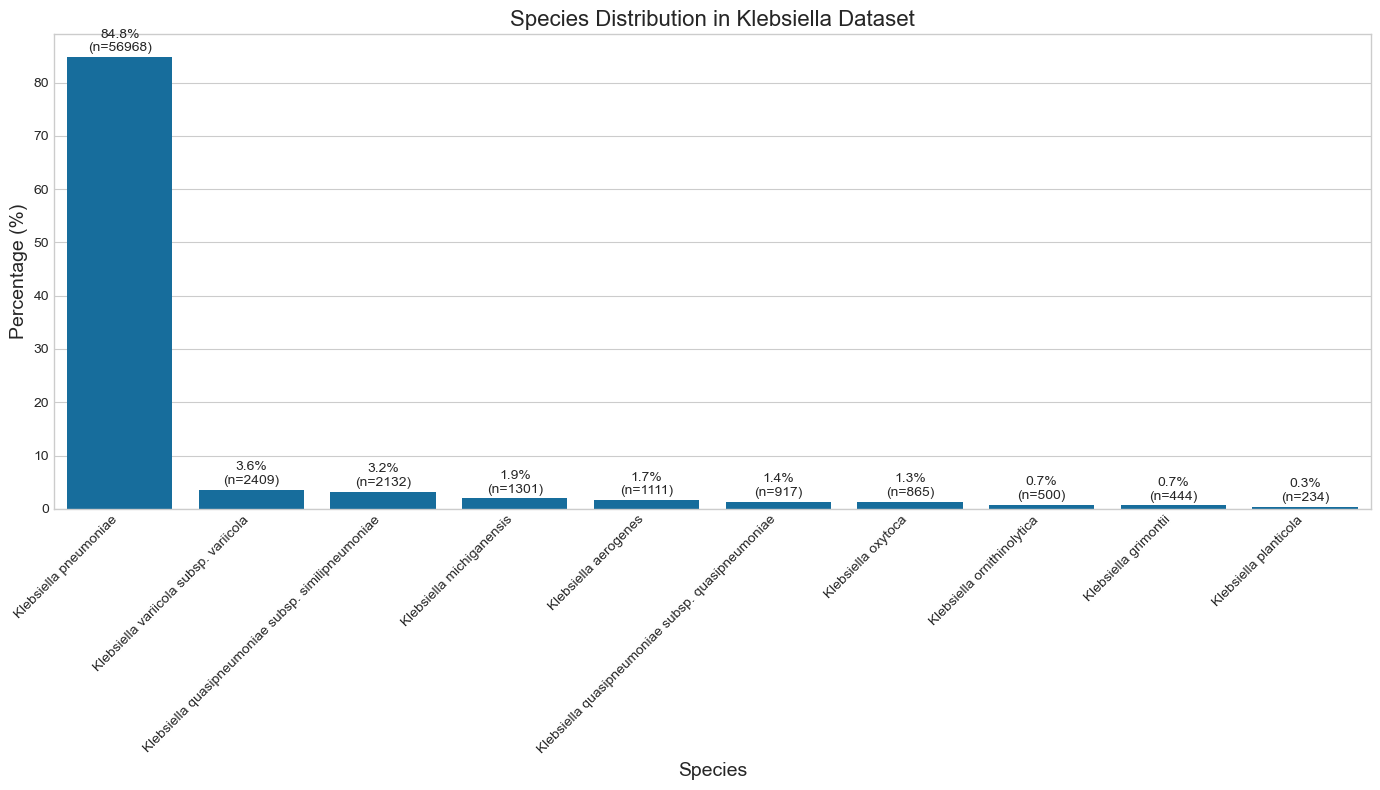

In [86]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
k_file = "/Users/davidabelson/Library/CloudStorage/OneDrive-UniversityofCambridge/Code_repos/md_curation/atb-0.2-kleborate.v2.3.2-merged.tsv"
kleborate_data = pd.read_csv(k_file, sep="\t")

# Count species and calculate percentages
species_counts = kleborate_data['species'].value_counts()
species_percent = (species_counts / len(kleborate_data) * 100).reset_index()
species_percent.columns = ['Species', 'Percentage']

# Set style for better visualization
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")

# Create the plot
plt.figure(figsize=(14, 8))
ax = sns.barplot(x='Species', y='Percentage', data=species_percent.head(10))
plt.title('Species Distribution in Klebsiella Dataset', fontsize=16)
plt.xlabel('Species', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Add percentage labels on top of bars
for i, p in enumerate(ax.patches):
    percentage = species_percent['Percentage'].iloc[i]
    count = species_counts.iloc[i]
    ax.annotate(f"{percentage:.1f}%\n(n={count})", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='bottom',
                fontsize=10)

plt.tight_layout()
plt.show()

# # Print the species distribution table for reference
# print("Species distribution:")
# for species, count in species_counts.items():
#     percentage = (count / len(kleborate_data)) * 100
#     print(f"{species}: {count} ({percentage:.2f}%)")

# K.pneumoniae ST distribution

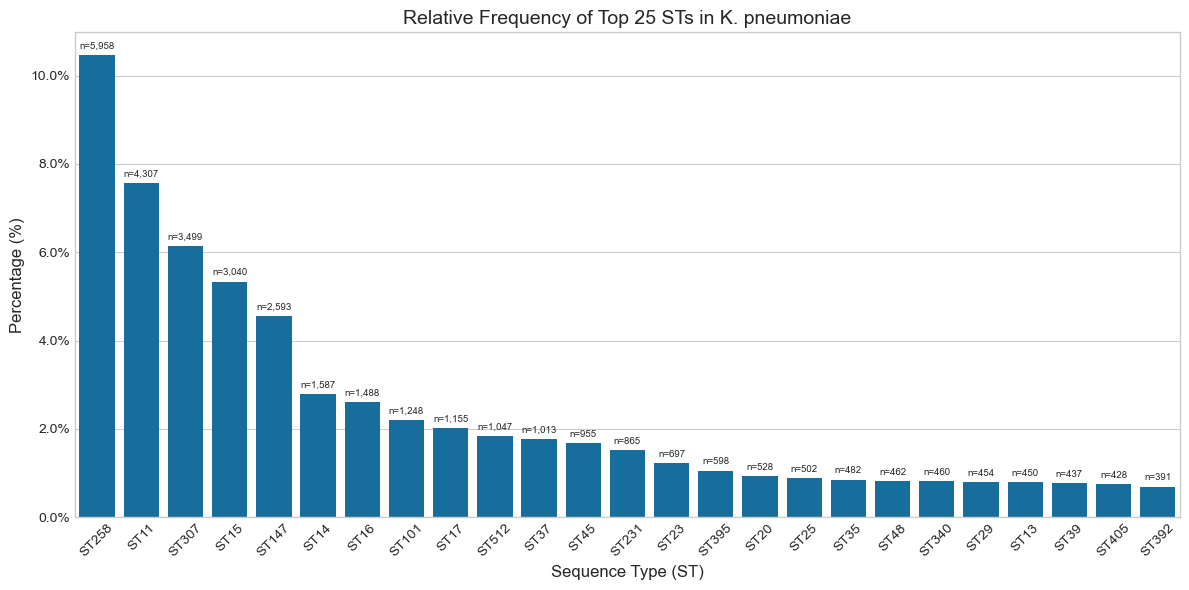

In [87]:
# Filter to k.pneumoniae only
kp1 = kleborate_data[kleborate_data['species'] == 'Klebsiella pneumoniae']

# Get the counts for each ST and sort them in descending order
st_counts = kp1['ST'].value_counts()

# 1. First graph: Distribution of ST types in K. pneumoniae
st_percent = (st_counts / len(kp1) * 100).reset_index()
st_percent.columns = ['ST', 'Percentage']

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='ST', y='Percentage', data=st_percent.head(25))
plt.title('Relative Frequency of Top 25 STs in K. pneumoniae', fontsize=14)
plt.xlabel('Sequence Type (ST)', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Add sample count (n) labels on top of bars
for i, p in enumerate(ax.patches):
    st_value = st_percent['ST'].iloc[i]
    count = st_counts[st_value]
    ax.annotate(f"n={count:,}", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.1),
                ha='center', va='bottom',
                fontsize=7)

plt.tight_layout()
plt.show()


/var/folders/wn/jcfcy14j4232dygbwnnqz6hw0000gn/T/ipykernel_78726/1522686234.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kp1['clonal_group'] = kp1['ST'].apply(get_clonal_group)
/var/folders/wn/jcfcy14j4232dygbwnnqz6hw0000gn/T/ipykernel_78726/1522686234.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  st_percent_top25['clonal_group'] = st_percent_top25['ST'].apply(get_clonal_group)


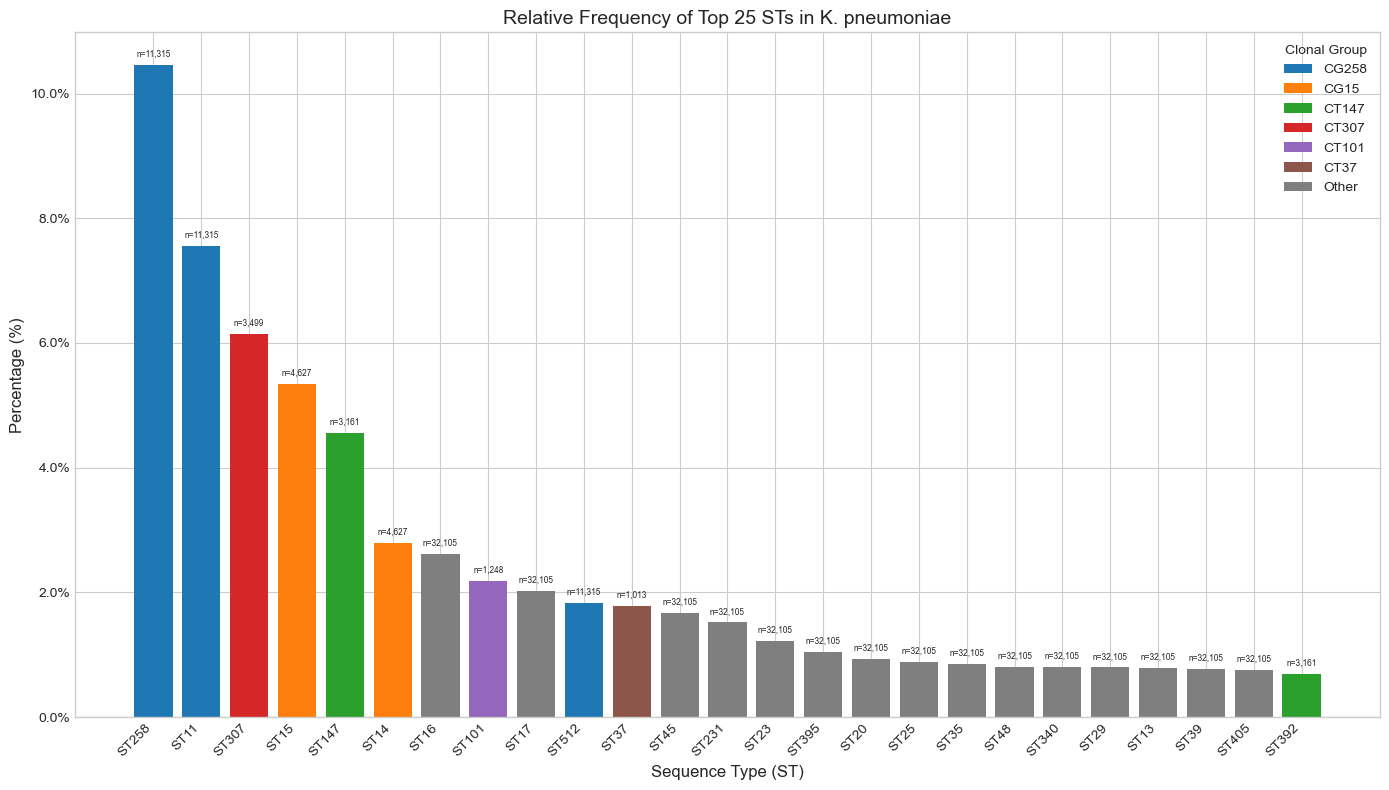

In [88]:
# Define clonal groups correctly
clonal_groups = {
    "CG258": ["ST258", "ST11", "ST512", "ST1326"],
    "CG15": ["ST15", "ST14"],
    "CT147": ["ST147", "ST392", "ST273"],
    "CT307": ["ST307"],
    "CT101": ["ST101"],
    "CT37": ["ST37"]
}

# Function to map ST to clonal group
def get_clonal_group(st):
    if pd.isna(st):
        return "Unknown"
    
    st_str = str(st)
    for group, sts in clonal_groups.items():
        if st_str in sts:
            return group
    return "Other"

# Add clonal group to the data
kp1['clonal_group'] = kp1['ST'].apply(get_clonal_group)

# Get the counts for each ST and sort them in descending order
st_counts = kp1['ST'].value_counts()
clonal_group_counts = kp1['clonal_group'].value_counts()
top_25_sts = st_counts.index[:25].tolist()

# Create a dataframe for plotting
st_percent = (st_counts / len(kp1) * 100).reset_index()
st_percent.columns = ['ST', 'Percentage']
st_percent_top25 = st_percent.head(25)

# Add clonal group information to the plotting dataframe
st_percent_top25['clonal_group'] = st_percent_top25['ST'].apply(get_clonal_group)

# Create a color map for clonal groups
clonal_group_colors = {
    "CG258": "#1f77b4",  # blue
    "CG15": "#ff7f0e",   # orange
    "CT147": "#2ca02c",  # green
    "CT307": "#d62728",  # red
    "CT101": "#9467bd",  # purple
    "CT37": "#8c564b",   # brown
    "Other": "#7f7f7f",  # gray
    "Unknown": "#bcbd22" # yellow
}

# Create a list of colors for the bars based on clonal group
bar_colors = [clonal_group_colors[group] for group in st_percent_top25['clonal_group']]

# Plot with colored bars by clonal group
plt.figure(figsize=(14, 8))
ax = plt.bar(st_percent_top25['ST'], st_percent_top25['Percentage'], color=bar_colors)
plt.title('Relative Frequency of Top 25 STs in K. pneumoniae', fontsize=14)
plt.xlabel('Sequence Type (ST)', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

# Add sample count (n) labels on top of bars
for i, st in enumerate(st_percent_top25['ST']):
    clonal_group = st_percent_top25['clonal_group'].iloc[i]
    count = clonal_group_counts[clonal_group]
    plt.text(i, st_percent_top25['Percentage'].iloc[i] + 0.1, f"n={count:,}", 
             ha='center', va='bottom',
             fontsize=6)

# Create a custom legend for clonal groups
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=group) 
                   for group, color in clonal_group_colors.items() 
                   if group in st_percent_top25['clonal_group'].values]
plt.legend(handles=legend_elements, title='Clonal Group', loc='upper right')

plt.tight_layout()
plt.show()

## O-type distribution in K.pneumoniae
### Filter data for top 10 STs

/var/folders/wn/jcfcy14j4232dygbwnnqz6hw0000gn/T/ipykernel_78726/754998656.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_st_data['O_locus_grouped'] = top_st_data['O_locus'].apply(map_o_type)


<Figure size 1400x800 with 0 Axes>

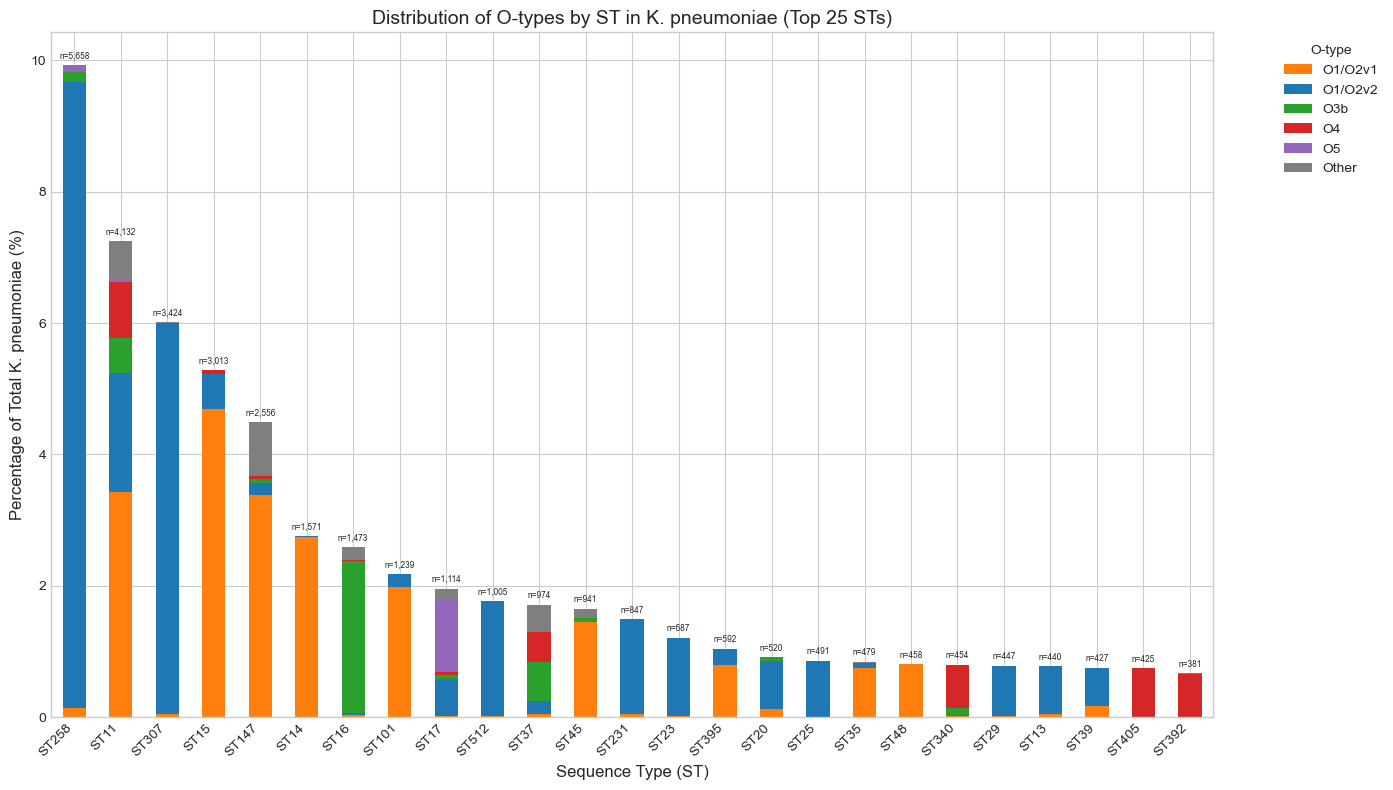


O-types kept as individual categories:
O1/O2v2: 46.23%
O1/O2v1: 35.04%
O3b: 6.64%
O4: 6.03%
O5: 2.16%

Number of O-types grouped as 'Other': 6


In [89]:
# Filter to k.pneumoniae only with high confidence O_locus
kp1_filtered = kp1[kp1['O_locus_confidence'].isin(["Perfect", "Very high", "High", "Good"])].copy()

# Get the top 25 STs from the original plot
top_25_sts = st_counts.index[:25].tolist()

# Filter data for top 25 STs
top_st_data = kp1_filtered[kp1_filtered['ST'].isin(top_25_sts)]
ordered_sts = sorted(top_25_sts, key=lambda x: st_counts[x], reverse=True)

# Calculate overall O-type frequencies
o_type_counts = top_st_data['O_locus'].value_counts()
o_type_percent = (o_type_counts / len(top_st_data) * 100).reset_index()
o_type_percent.columns = ['O_locus', 'Percentage']

# Define the top 7 O-types (with percentage > 1%)
top_o_types = ["O1/O2v2", "O1/O2v1", "O3b", "O4", "O5"]

# Define a color dictionary for the top 7 O-types and "Other"
color_dict = {
    "O1/O2v2": "#1f77b4",  # blue
    "O1/O2v1": "#ff7f0e",  # orange
    "O3b": "#2ca02c",      # green
    "O4": "#d62728",       # red
    "O5": "#9467bd",       # purple
    "Other": "#7f7f7f"     # gray
}

# Create a function to map rare O-types to "Other"
def map_o_type(o_type):
    if o_type in top_o_types:
        return o_type
    return "Other"

# Apply the mapping
top_st_data['O_locus_grouped'] = top_st_data['O_locus'].apply(map_o_type)

# Create a DataFrame for plotting
st_o_type_counts = top_st_data.groupby(['ST', 'O_locus_grouped']).size().reset_index(name='count')

# Calculate percentage of total k.pneumoniae population
total_kp = len(kp1)
st_o_type_counts['percentage'] = st_o_type_counts['count'] / total_kp * 100

# Create a pivot table for plotting
pivot_data = st_o_type_counts.pivot_table(
    index='ST',
    columns='O_locus_grouped',
    values='percentage',
    fill_value=0
)

# Reindex to ensure consistent ST ordering
pivot_data = pivot_data.reindex(ordered_sts)

# Ensure "Other" is the last column if it exists
if "Other" in pivot_data.columns:
    cols = [col for col in pivot_data.columns if col != "Other"] + ["Other"]
    pivot_data = pivot_data[cols]

# Create a color list for plotting that matches the order of columns
color_list = [color_dict[col] for col in pivot_data.columns]

# Plot
plt.figure(figsize=(14, 8))
pivot_data.plot(kind='bar', stacked=True, figsize=(14, 8), color=color_list)
plt.title('Distribution of O-types by ST in K. pneumoniae (Top 25 STs)', fontsize=14)
plt.xlabel('Sequence Type (ST)', fontsize=12)
plt.ylabel('Percentage of Total K. pneumoniae (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Consistent with first plot
plt.legend(title='O-type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add sample size labels on top of each bar
for i, st in enumerate(pivot_data.index):
    # Get count from original st_counts (not filtered)
    count = st_counts[st]
    
    # Get filtered count for this ST
    filtered_count = len(top_st_data[top_st_data['ST'] == st])
    
    # Calculate total height of this stacked bar
    total_height = pivot_data.loc[st].sum()
    
    # Show both counts: total and high-confidence
    plt.text(i, total_height + 0.1, f'n={filtered_count:,}', ha='center', fontsize=6)

plt.tight_layout()
plt.show()

# Print summary of the grouping
print("\nO-types kept as individual categories:")
for o_type in top_o_types:
    row = o_type_percent[o_type_percent['O_locus'] == o_type]
    if not row.empty:
        percentage = row['Percentage'].values[0]
        print(f"{o_type}: {percentage:.2f}%")

print(f"\nNumber of O-types grouped as 'Other': {len(o_type_counts) - len(top_o_types)}")

Samples with K_locus_confidence 'None': 0

Unique values in K_locus_confidence:
K_locus_confidence
Very high    28303
Good         16904
High          4243
Perfect       1690
Low            731
Name: count, dtype: int64

Samples with K_locus 'Mixed k-locus' after transformation: 0
Samples with 'Mixed k-locus' in top 25 STs: 0

K-locus frequencies in samples (top 15):
            K_locus  Percentage
0             KL107   10.856137
1             KL102    9.444637
2              KL64    9.104030
3             KL106    6.976677
4               KL2    5.891352
5              KL51    5.856714
6              KL24    5.833622
7              KL15    3.152061
8              KL17    3.062579
9             KL112    2.710426
10            KL105    2.488165
11             KL10    2.300543
12             KL62    1.994573
13  unknown (KL107)    1.948389
14              KL1    1.809837

'Mixed k-locus' not found in frequency table!

Grouped K-locus counts:
K_locus_grouped
Other              7013
KL107 

/var/folders/wn/jcfcy14j4232dygbwnnqz6hw0000gn/T/ipykernel_78726/1072194183.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_st_data['K_locus_grouped'] = top_st_data['K_locus'].apply(map_k_locus)
/var/folders/wn/jcfcy14j4232dygbwnnqz6hw0000gn/T/ipykernel_78726/1072194183.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', max(num_regular_cols, 20))


<Figure size 1400x800 with 0 Axes>

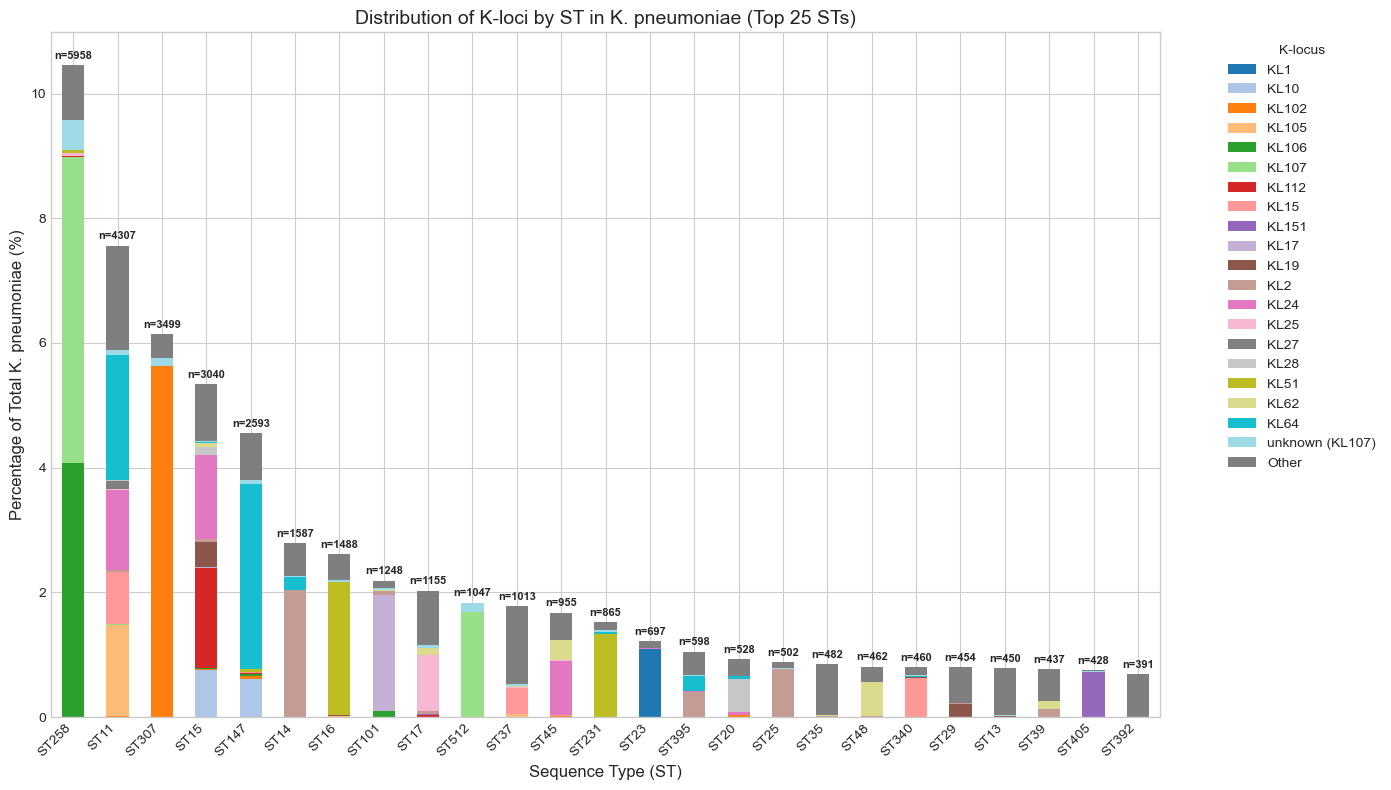


K-loci with ≥1.0% frequency kept as individual categories:
KL107, KL102, KL64, KL106, KL2, KL51, KL24, KL15, KL17, KL112, KL105, KL10, KL62, unknown (KL107), KL1, KL25, KL151, KL27, KL28, KL19

Number of K-loci grouped as 'Other': 161


In [90]:
# Filter to k.pneumoniae only
kp1_filtered = kp1.copy()

# Check how many samples have K_locus_confidence as "None"
none_confidence_count = kp1_filtered[kp1_filtered['K_locus_confidence'] == "None"].shape[0]
print(f"Samples with K_locus_confidence 'None': {none_confidence_count}")

# Check the unique values in K_locus_confidence
print("\nUnique values in K_locus_confidence:")
print(kp1_filtered['K_locus_confidence'].value_counts())

# Set K_locus to "Mixed k-locus" where K_locus_confidence is "None"
kp1_filtered.loc[kp1_filtered['K_locus_confidence'] == "None", 'K_locus'] = "Mixed k-locus"

# Verify the change
mixed_count = kp1_filtered[kp1_filtered['K_locus'] == "Mixed k-locus"].shape[0]
print(f"\nSamples with K_locus 'Mixed k-locus' after transformation: {mixed_count}")

# Get the top 25 STs from the original plot
top_25_sts = st_counts.index[:25].tolist()

# Filter data for top 25 STs
top_st_data = kp1_filtered[kp1_filtered['ST'].isin(top_25_sts)]
ordered_sts = sorted(top_25_sts, key=lambda x: st_counts[x], reverse=True)

# Check how many "Mixed k-locus" samples are in the top 25 STs
mixed_in_top25 = top_st_data[top_st_data['K_locus'] == "Mixed k-locus"].shape[0]
print(f"Samples with 'Mixed k-locus' in top 25 STs: {mixed_in_top25}")

# Calculate overall K-locus frequencies
k_locus_counts = top_st_data['K_locus'].value_counts()
k_locus_percent = (k_locus_counts / len(top_st_data) * 100).reset_index()
k_locus_percent.columns = ['K_locus', 'Percentage']

# Display the frequency table
print("\nK-locus frequencies in samples (top 15):")
print(k_locus_percent.head(15))

# Check if "Mixed k-locus" is in the frequency table
if "Mixed k-locus" in k_locus_counts:
    mixed_percent = k_locus_percent[k_locus_percent['K_locus'] == "Mixed k-locus"]['Percentage'].values[0]
    print(f"\n'Mixed k-locus' percentage: {mixed_percent:.2f}%")
    print(f"'Mixed k-locus' rank: {k_locus_counts.index.get_loc('Mixed k-locus') + 1} out of {len(k_locus_counts)}")
else:
    print("\n'Mixed k-locus' not found in frequency table!")

# Define threshold for "Other" category (1%)
threshold = 1.0
common_k_loci = k_locus_percent[k_locus_percent['Percentage'] >= threshold]['K_locus'].tolist()

# Ensure "Mixed k-locus" is always kept as a separate category
if "Mixed k-locus" not in common_k_loci and "Mixed k-locus" in k_locus_counts:
    common_k_loci.append("Mixed k-locus")
    print("\nAdded 'Mixed k-locus' to common_k_loci even though it's below threshold")

# Create a function to map rare K-loci to "Other"
def map_k_locus(k_locus):
    if k_locus in common_k_loci:
        return k_locus
    return "Other"

# Apply the mapping
top_st_data['K_locus_grouped'] = top_st_data['K_locus'].apply(map_k_locus)

# Check the distribution of grouped K-loci
grouped_counts = top_st_data['K_locus_grouped'].value_counts()
print("\nGrouped K-locus counts:")
print(grouped_counts)

# Create a DataFrame for plotting
st_k_locus_counts = top_st_data.groupby(['ST', 'K_locus_grouped']).size().reset_index(name='count')

# Calculate percentage of total k.pneumoniae population
total_kp = len(kp1)
st_k_locus_counts['percentage'] = st_k_locus_counts['count'] / total_kp * 100

# Create a pivot table for plotting
pivot_data = st_k_locus_counts.pivot_table(
    index='ST',
    columns='K_locus_grouped',
    values='percentage',
    fill_value=0
)

# Reindex to ensure consistent ST ordering
pivot_data = pivot_data.reindex(ordered_sts)

# Ensure "Other" and "Mixed k-locus" are the last columns if they exist
special_cols = ["Mixed k-locus", "Other"]
regular_cols = [col for col in pivot_data.columns if col not in special_cols]
final_cols = regular_cols + [col for col in special_cols if col in pivot_data.columns]
pivot_data = pivot_data[final_cols]

# Create a color palette for the K-loci
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Generate colors for all categories except special ones
num_regular_cols = len(regular_cols)
cmap = cm.get_cmap('tab20', max(num_regular_cols, 20))
color_list = [mcolors.rgb2hex(cmap(i % 20)) for i in range(num_regular_cols)]

# Add special colors for "Mixed k-locus" and "Other"
if "Mixed k-locus" in pivot_data.columns:
    color_list.append("#8c564b")  # brown for Mixed k-locus
if "Other" in pivot_data.columns:
    color_list.append("#7f7f7f")  # gray for Other

# Plot
plt.figure(figsize=(14, 8))
pivot_data.plot(kind='bar', stacked=True, figsize=(14, 8), color=color_list)
plt.title('Distribution of K-loci by ST in K. pneumoniae (Top 25 STs)', fontsize=14)
plt.xlabel('Sequence Type (ST)', fontsize=12)
plt.ylabel('Percentage of Total K. pneumoniae (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Consistent with first plot
plt.legend(title='K-locus', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add sample size labels on top of each bar
for i, st in enumerate(pivot_data.index):
    # Get count from original st_counts
    count = st_counts[st]
    
    # Calculate total height of this stacked bar
    total_height = pivot_data.loc[st].sum()
    
    # Show count
    plt.text(i, total_height + 0.1, f'n={count}', ha='center', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.show()

# Print summary of the grouping
print(f"\nK-loci with ≥{threshold}% frequency kept as individual categories:")
print(", ".join(common_k_loci))
print(f"\nNumber of K-loci grouped as 'Other': {len(k_locus_counts) - len(common_k_loci) - ('Mixed k-locus' in common_k_loci)}")

# Key Genes

AMR genes with frequency between 20-80%:
Aac3-IIa_AGly    0.209707
AacAad_AGly      0.415751
AadA_AGly        0.353480
Aph3''Ia_AGly    0.215201
CTX-M-1_Bla      0.270147
CatA1_Phe        0.222527
CatBx_Phe        0.202381
DfrA5_Tmt        0.239011
DfrA_Tmt         0.225275
KPC-1_Bla        0.201465
MphA_MLS         0.243590
OXA-1_Bla        0.210623
StrA_AGly        0.293040
StrB_AGly        0.288462
SulII_Sul        0.284799
SulI_Sul         0.378205
TEM-1D_Bla       0.437729
dtype: float64

Hypervirulence genes with frequency between 20-80%:
ybtA    0.435897
ybtE    0.434982
ybtP    0.434066
ybtQ    0.435897
ybtS    0.434982
ybtT    0.434982
ybtU    0.434066
ybtX    0.434066
irp1    0.434066
irp2    0.430403
dtype: float64

After removing 'ST' prefix:
First few top_25_sts_numbers: ['258', '11', '307', '15', '147']
First few ordered_sts_numbers: ['258', '11', '307', '15', '147']

Number of common STs after removing 'ST' prefix: 21
Common STs: ['101', '11', '14', '147', '15', '16', '1

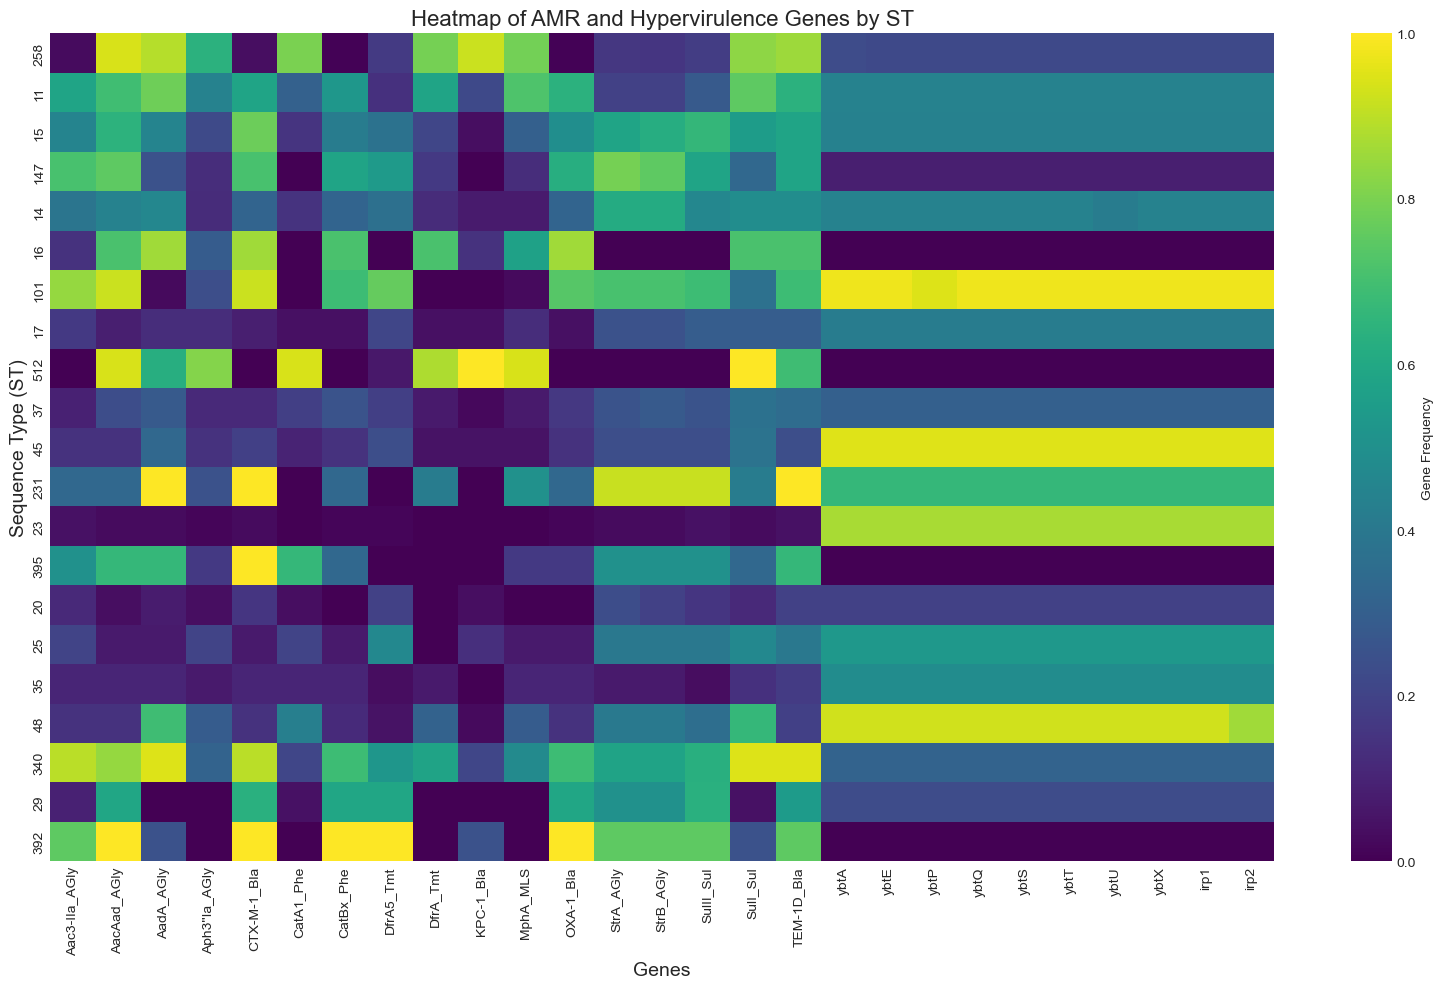

In [93]:
holt_df = pd.read_csv("/Users/davidabelson/Library/CloudStorage/OneDrive-UniversityofCambridge/Code_repos/md_curation/wyres_holt_plos1_2019_direct_evolutionary_dynamics.csv")
# xls columns W-EC = column number 22-132
AMR_columns = holt_df.iloc[:, 21:132]
HV_columns = holt_df.iloc[:, 133:171]

# Convert columns to numeric where possible to ensure proper mean calculation
for col in AMR_columns.columns:
    AMR_columns[col] = pd.to_numeric(AMR_columns[col], errors='coerce')
    
for col in HV_columns.columns:
    HV_columns[col] = pd.to_numeric(HV_columns[col], errors='coerce')

# Calculate mean of each column
AMR_mean = AMR_columns.mean()
HV_mean = HV_columns.mean()

# Select columns with mean > 0.2 and < 0.8
AMR_selected = AMR_mean[(AMR_mean > 0.2) & (AMR_mean < 0.8)]
HV_selected = HV_mean[(HV_mean > 0.2) & (HV_mean < 0.8)]

print("AMR genes with frequency between 20-80%:")
print(AMR_selected)
print("\nHypervirulence genes with frequency between 20-80%:")
print(HV_selected)

# Convert ST values to strings in both dataframes
holt_df['ST'] = holt_df['ST'].astype(str)

# Create a version of top_25_sts without the "ST" prefix
top_25_sts_numbers = []
for st in top_25_sts:
    # Remove "ST" prefix if it exists
    if isinstance(st, str) and st.startswith('ST'):
        top_25_sts_numbers.append(st[2:])  # Remove the first 2 characters ('ST')
    else:
        top_25_sts_numbers.append(str(st))

# Create a version of ordered_sts without the "ST" prefix
ordered_sts_numbers = []
for st in ordered_sts:
    # Remove "ST" prefix if it exists
    if isinstance(st, str) and st.startswith('ST'):
        ordered_sts_numbers.append(st[2:])  # Remove the first 2 characters ('ST')
    else:
        ordered_sts_numbers.append(str(st))

# Print diagnostic information
print("\nAfter removing 'ST' prefix:")
print(f"First few top_25_sts_numbers: {top_25_sts_numbers[:5]}")
print(f"First few ordered_sts_numbers: {ordered_sts_numbers[:5]}")

# Check for common values after removing the "ST" prefix
common_sts = set(holt_df['ST'].unique()).intersection(set(top_25_sts_numbers))
print(f"\nNumber of common STs after removing 'ST' prefix: {len(common_sts)}")
print(f"Common STs: {sorted(list(common_sts))}")

# Now I want a heat-map of these genes in the 25 ST in the holt_df
# Create a heatmap of the selected AMR and HV genes

# Correctly select the columns: 'ST' and the columns from AMR_selected and HV_selected
selected_columns = ['ST'] + list(AMR_selected.index) + list(HV_selected.index)
holt_df_selected = holt_df[selected_columns]

# Filter for rows where 'ST' is in the common STs (after removing 'ST' prefix)
holt_df_selected = holt_df_selected[holt_df_selected['ST'].isin(common_sts)]

if len(holt_df_selected) == 0:
    print("Warning: No data found for the top 25 STs in the holt_df dataset even after removing 'ST' prefix.")
    
    # If we still don't have matches, use the top STs from holt_df
    top_sts_holt = holt_df['ST'].value_counts().head(25).index.tolist()
    print(f"Using top 25 STs from holt_df instead: {top_sts_holt}")
    
    # Use these STs for the heatmap
    holt_df_selected = holt_df[selected_columns]
    holt_df_selected = holt_df_selected[holt_df_selected['ST'].isin(top_sts_holt)]
    
    # Group by ST and calculate mean of the selected columns
    holt_df_grouped = holt_df_selected.groupby('ST').mean()
    
    # Display as heatmap
    plt.figure(figsize=(16, 10))
    sns.heatmap(holt_df_grouped, cmap='viridis', annot=False, cbar_kws={'label': 'Gene Frequency'})
    plt.title('Heatmap of AMR and Hypervirulence Genes by ST (Top 25 from Holt dataset)', fontsize=16)
    plt.xlabel('Genes', fontsize=14)
    plt.ylabel('Sequence Type (ST)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    # Print the number of samples for each ST in the filtered dataset
    st_counts = holt_df_selected['ST'].value_counts()
    print("\nNumber of samples for each ST in the filtered dataset:")
    print(st_counts)
    
    # Group by ST and calculate mean of the selected columns
    holt_df_grouped = holt_df_selected.groupby('ST').mean()
    
    # Try to reorder based on ordered_sts_numbers
    common_ordered_sts = [st for st in ordered_sts_numbers if st in common_sts]
    if common_ordered_sts:
        holt_df_grouped = holt_df_grouped.reindex(common_ordered_sts)
        print(f"\nReordered heatmap rows to match ordered_sts. Using {len(common_ordered_sts)} STs.")
    
    # Display as heatmap
    plt.figure(figsize=(16, 10))
    sns.heatmap(holt_df_grouped, cmap='viridis', annot=False, cbar_kws={'label': 'Gene Frequency'})
    plt.title('Heatmap of AMR and Hypervirulence Genes by ST', fontsize=16)
    plt.xlabel('Genes', fontsize=14)
    plt.ylabel('Sequence Type (ST)', fontsize=14)
    plt.tight_layout()
    plt.show()



## Yersinabactin, ybt locus
- Frequently acquired and lost by MDR clones 
- Present in 40% of K. pnuemoniae general population

### Colibactin genotoxin
- Induces eukaryotic cell death and promotes invasion to blood from intestines

## RMP genes of hypermucoidy
- Genes upregulate capsult expression to generate hypermucoidy state 

## Acquisition of specific AMR genes